# FIR Filter Theory and Implementation

In [14]:
from matplotlib.pyplot import (
    figure,
    grid,
    legend,
    plot,
    show,
    title,
    xlabel,
    ylabel,
)
from numpy import arange, linspace, pi, sin
from scipy.fftpack import fft
from scipy.signal import firwin, lfilter

## Generate a sample noisy signal

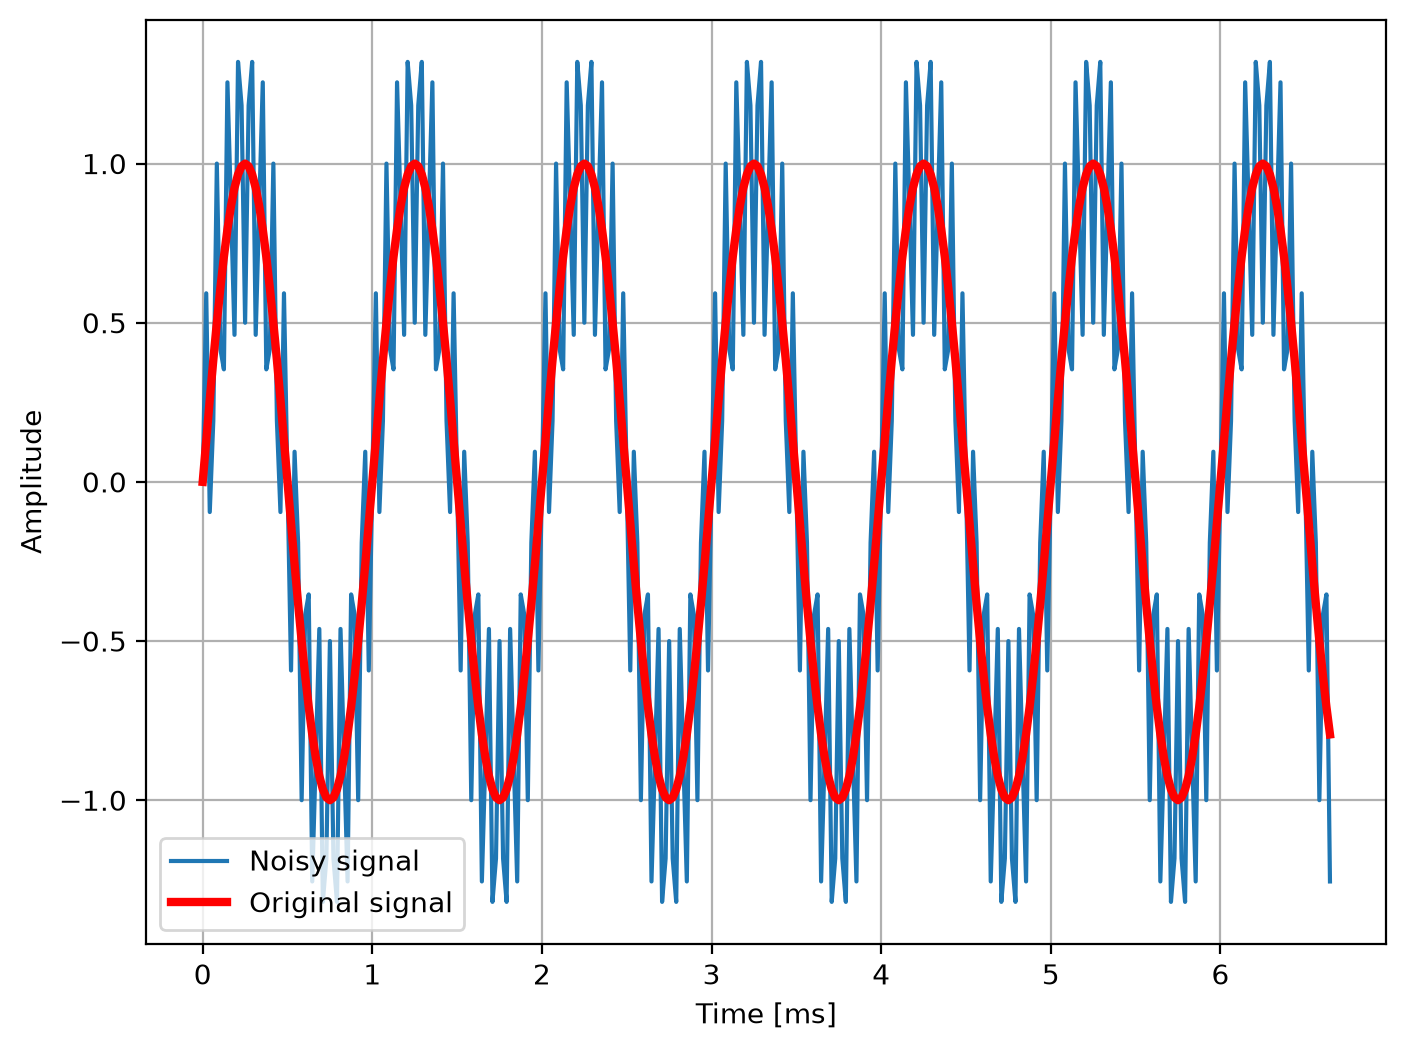

In [22]:
sampling_freq_hz = 48e3
n_samples = 320

noise_freq_hz = 15e3
noise_amp = 0.5

signal_freq_hz = 1e3
signal_amp = 1

t = arange(n_samples) / sampling_freq_hz
t_ms = t * 1e3

noise = noise_amp * sin(2 * pi * noise_freq_hz * t)
signal = signal_amp * sin(2 * pi * signal_freq_hz * t)
noisy_signal = noise + signal

figure(1, figsize=(8, 6), dpi=200)
plot(t_ms, noisy_signal, label="Noisy signal")
plot(t_ms, signal, "r-", linewidth=3, label="Original signal")
xlabel("Time [ms]")
ylabel("Amplitude")
legend()
grid(True)
show()

## Calculate and plot the original signal and noisy signal's FFT

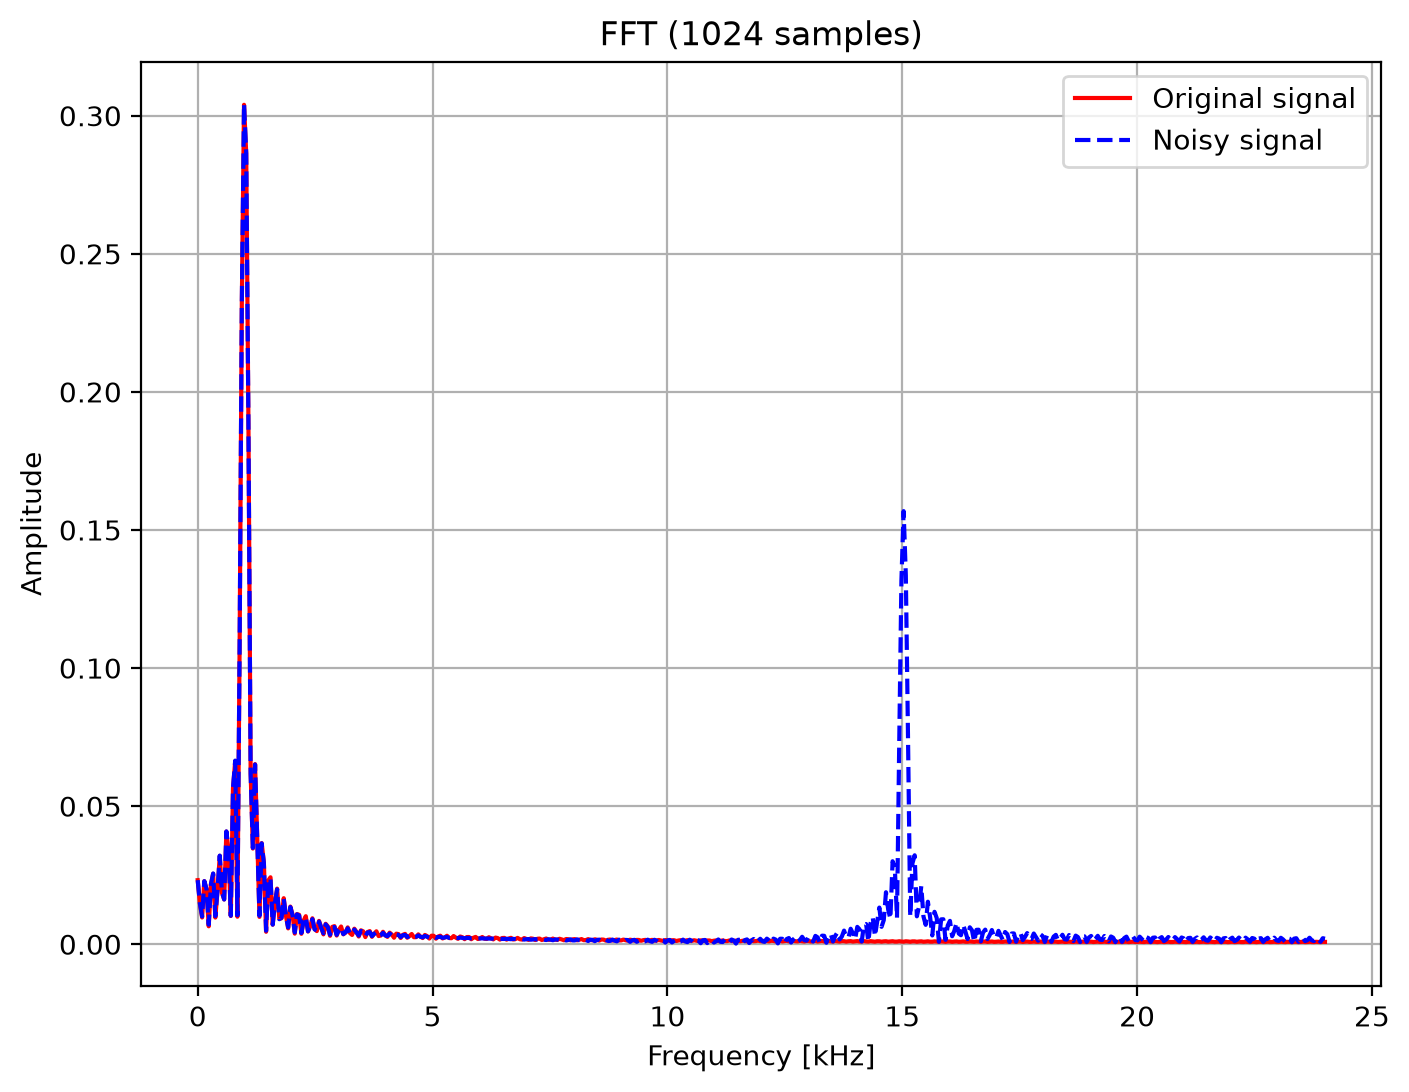

In [30]:
n_fft = 1024
fft_signal = fft(signal, n_fft)
fft_noisy_signal = fft(noisy_signal, n_fft)
x_fft = linspace(0.0, sampling_freq_hz / 2, n_fft // 2)
x_fft_khz = x_fft / 1e3

figure(2, figsize=(8, 6), dpi=200)
title(f"FFT ({n_fft} samples)")
plot(
    x_fft_khz,
    2.0 / n_fft * abs(fft_signal[0 : n_fft // 2]),
    "r",
    label="Original signal",
)
plot(
    x_fft_khz,
    2.0 / n_fft * abs(fft_noisy_signal[0 : n_fft // 2]),
    "b--",
    label="Noisy signal",
)
xlabel("Frequency [kHz]")
ylabel("Amplitude")
legend()
grid(True)
show()

## Calculate the FIR filter coefficients

In [31]:
# The cutoff frequency of the filter
cutoff_freq_hz = 6e3

# Length of the filter (number of coefficients, i.e. the filter order + 1)
n_filter_taps = 29

# Use firwin to create a lowpass FIR filter
fir_filter_coeffs = firwin(n_filter_taps, cutoff_freq_hz, fs=sampling_freq_hz)

# Use lfilter to filter the signal with the FIR filter
filtered_signal = lfilter(fir_filter_coeffs, 1.0, noisy_signal)

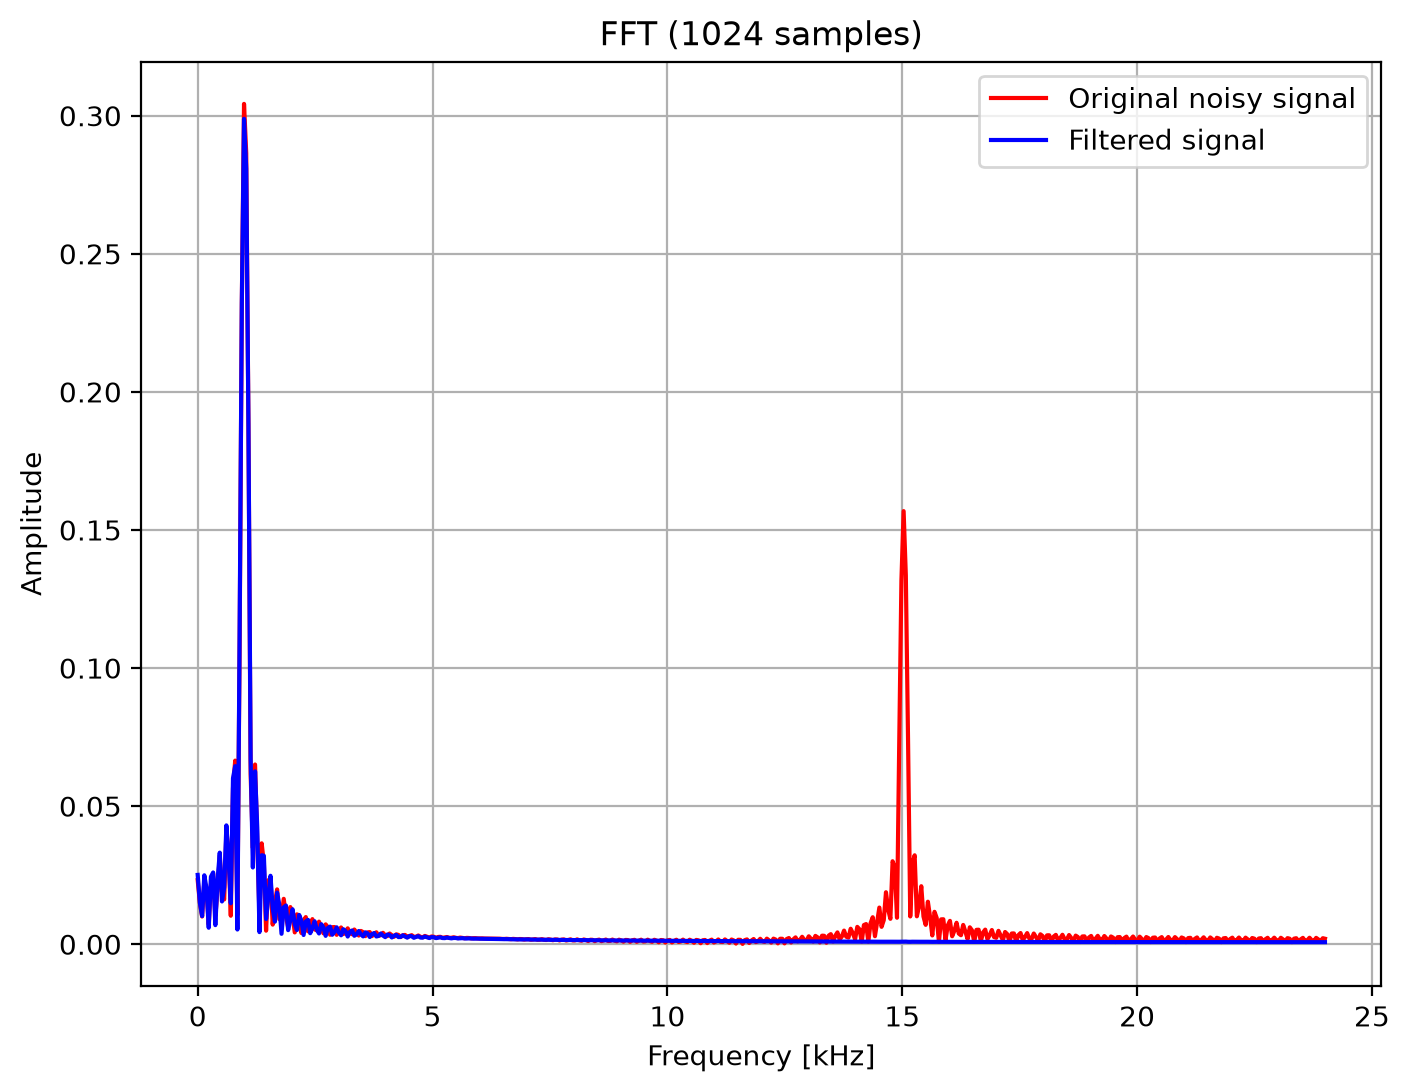

In [32]:
n_fft = 1024
fft_noisy_signal = fft(noisy_signal, n_fft)
fft_noisy_signal_right_side = 2.0 / n_fft * abs(fft_noisy_signal[0 : n_fft // 2])
fft_filtered_signal = fft(filtered_signal, n_fft)
fft_filtered_signal_right_side = 2.0 / n_fft * abs(fft_filtered_signal[0 : n_fft // 2])
x_fft = linspace(0, sampling_freq_hz / 2, n_fft // 2)
x_fft_khz = x_fft / 1e3

figure(2, figsize=(8, 6), dpi=200)
title(f"FFT ({n_fft} samples)")
plot(
    x_fft_khz,
    fft_noisy_signal_right_side,
    "r",
    label="Original noisy signal",
)
plot(
    x_fft_khz,
    fft_filtered_signal_right_side,
    "b",
    label="Filtered signal",
)
xlabel("Frequency [kHz]")
ylabel("Amplitude")
legend()
grid(True)
show()